In [193]:
# These are actually all the imports we need
import numpy as np # For calculations and linear algebra
import matplotlib.pyplot as plt # For plotting
import math
    
# Some settings to make the figures more readable 
%matplotlib inline 
from pylab import rcParams
rcParams['figure.figsize'] = 20, 15 # Bigger figures
rcParams.update({'font.size': 25}) # Bigger text (for labels)
from warnings import filterwarnings
filterwarnings('ignore')

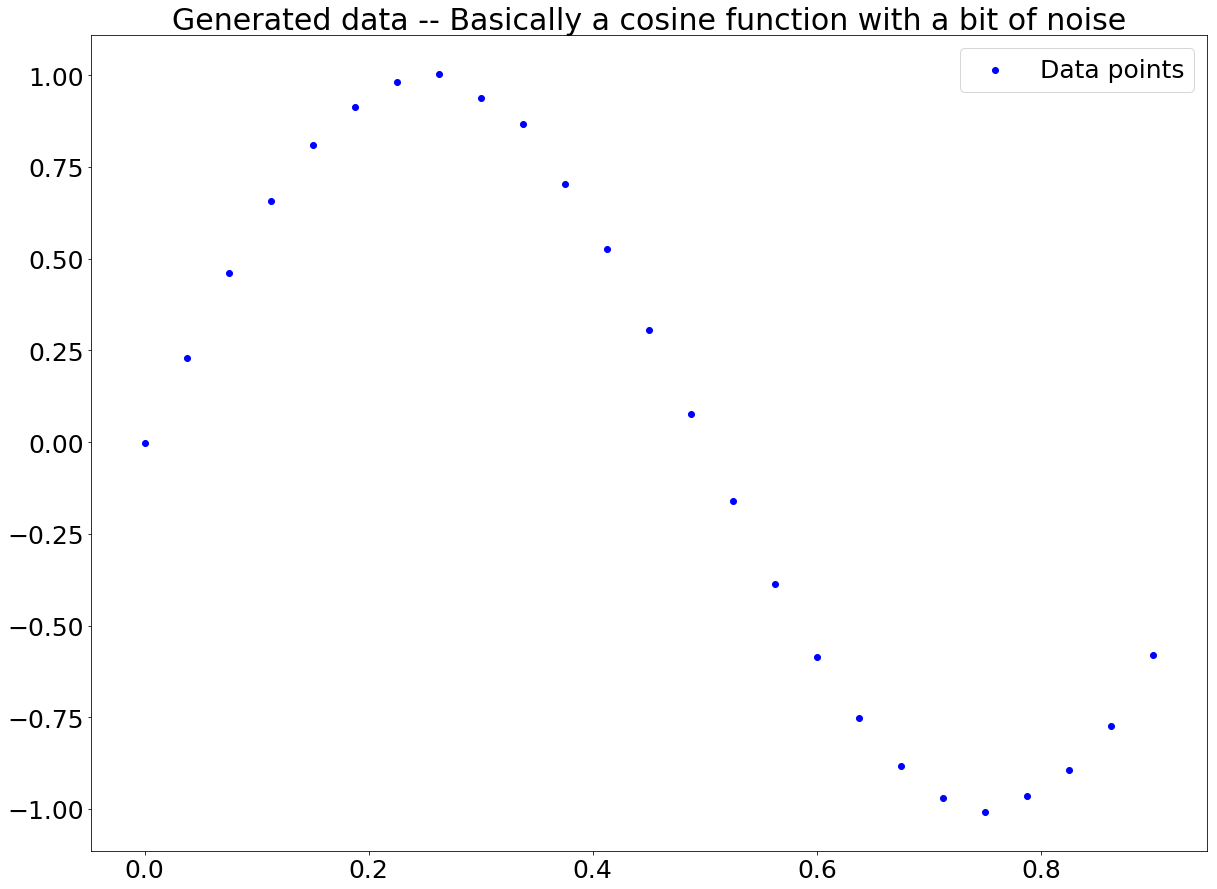

In [204]:
N = 25 # Number of data points
x = np.reshape(np.linspace(0, 0.9, N), (N, 1)) # 0~9之间产生N个数，并转成行向量x
test_sigma=0.1
y = np.sin(2*math.pi*x) + 0.1 *np.random.normal(0, test_sigma, [25,1])
 # 从x按公式生成y并加噪声
def plot_it(title):
    plt.scatter(x, y, color='blue',label='Data points')
    plt.title(title)
    plt.legend()
    plt.show()
    
    

plot_it('Generated data -- Basically a cosine function with a bit of noise')

In [195]:
def gaussian(x, mean, scale):
    """Enhance x with Gaussian features 
    
    Args:
        x (list): list of 1-dimensional observations
        mean (list): list of means for the Gaussian functions
        scale (float): variance for the Gaussian functions"""
    return np.array(np.append(np.ones(x.shape[0]), # Add bias
                              np.array([np.exp(-(x-mu) ** 2/(2 * scale ** 2)) for mu in mean])).reshape(1+len(mean), len(x)).T)
#     return np.array(np.array([np.exp(-(x-mu) ** 2/(2 * scale ** 2)) for mu in mean]).reshape(len(mean), len(x)).T)

In [196]:
print(np.shape(gaussian(x,np.linspace(-0.5,1,25),0.1)))
print(np.shape(y))

(25, 26)
(25, 1)


(200, 4) (4, 1)
[[-1.35740909]
 [ 0.8177897 ]
 [ 1.84102015]
 [ 0.43528176]]
1


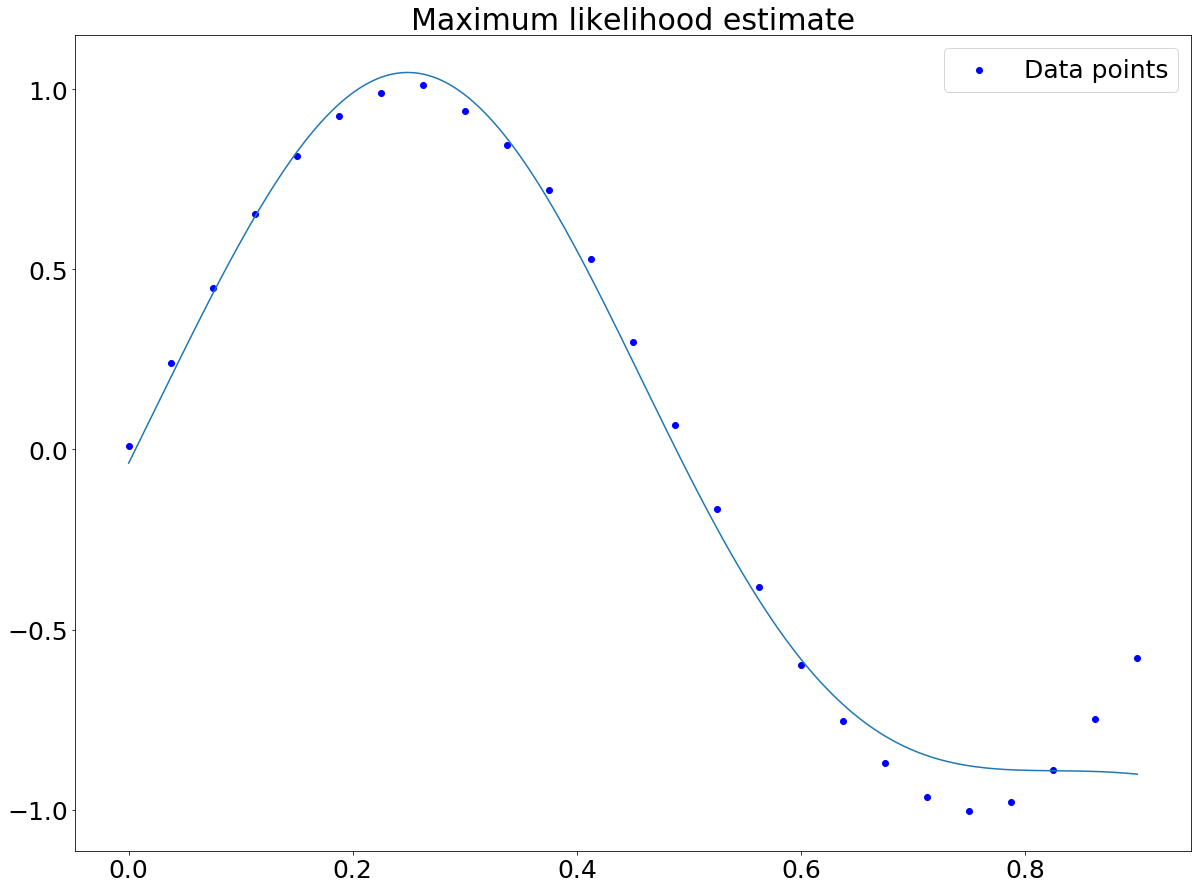

In [197]:
#最大似然估计
train_shape=200
points = np.reshape(np.linspace(0, 0.9, train_shape), (train_shape, 1)) # Use 200 points for smooth curves
train_sigma=0.2
X_200 = gaussian(points, [0.1, 0.3, 0.9], train_sigma) # Make a matrix using 3 different Gaussians.
                      # Note that different parameters lead to different results
# y_200 = np.cos(10*points**2) + 0.1 * np.sin(100*points) # Generate the equivalent targets
Y_200 = np.sin(2*math.pi*points) + 0.1 *np.random.normal(0, sigma, [train_shape,1])#编一个训练集或者测试集
w = np.linalg.inv(X_200.T @ X_200) @ X_200.T @ Y_200 # `@` is matrix multiplication
print(np.shape(X_200),np.shape(w))
print(w)
print(x.shape[1])
plt.plot(points, X_200 @ w) # Xw rather than w^Tx because X is now a vector of all data points
plot_it('Maximum likelihood estimate') 

In [198]:
# Generate a matrix X with 10 Gaussian functions
# X = gaussian(x, np.linspace(-0.5, 1, 10), 0.1)
X_200 = gaussian(points, [0.1, 0.3, 0.9], train_sigma)#这里X_200是基函数
# I'll just set S to the identity matrix
S = np.identity(X_200.shape[1])
# Set the noise to a a parameter
sigma = np.sqrt(train_sigma)

# Posterior parameters
S_post = np.linalg.inv(np.linalg.inv(S) + train_sigma ** (-2) * X_200.T @ X_200)
m_post = S_post @ (train_sigma ** (-2) * X_200.T @ Y_200)
print(np.shape(m_post))
print(np.shape(S_post))
print(np.shape(X_200))

(4, 1)
(4, 4)
(200, 4)


(200, 1)
(200, 4)
(4,)
(4,)
(4,)
(4,)


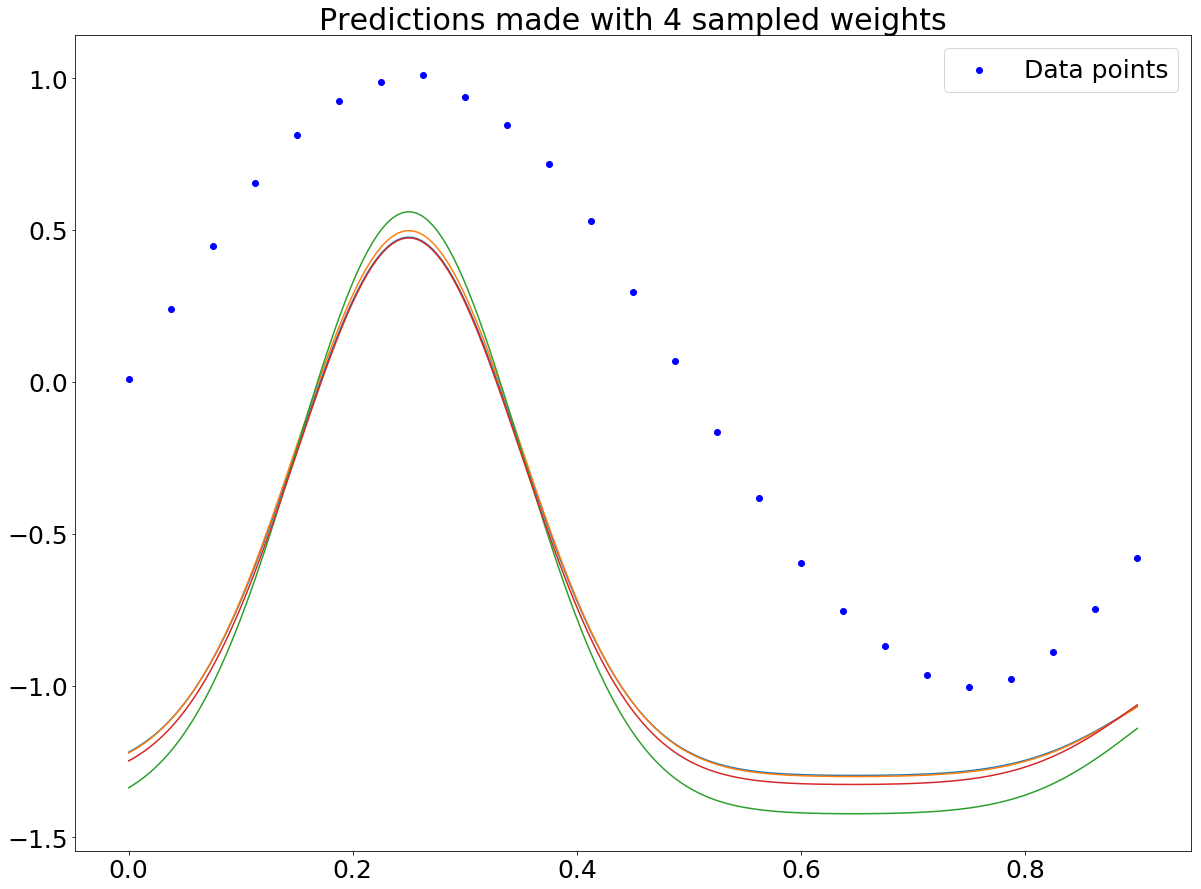

In [203]:
n_weights = 4
X = gaussian(points, np.linspace(-0.5, 1, 3), 0.1) 
print(np.shape(points))
print(np.shape(X))
def plot_some_functions(n_weights):
    for _ in range(n_weights):
        sampled_w = np.random.multivariate_normal(np.squeeze(m_post), S_post)
        print(np.shape(sampled_w))
#         np.reshape(sampled_w,(4*1))
#         print(np.shape(sampled_w))

        plt.plot(points, X@ (sampled_w))
plot_some_functions(n_weights)   
plot_it('Predictions made with {} sampled weights'.format(n_weights))

In [190]:
# Generate a matrix X with 10 Gaussian functions
X = gaussian(x, np.linspace(-0.5, 1, 10), 0.7) #训练集，x是0~0.9之间的25个均匀分布的数
# I'll just set S to the identity matrix
S = np.identity(x.shape[1])
# Set the noise to a a parameter
sigma = np.sqrt(0.1)
print(np.shape(X))
 
# Posterior parameters
S_post = np.linalg.inv(np.linalg.inv(S) + sigma ** (-2) * X.T @ X)
m_post = S_post @ (sigma ** (-2) * X.T @ y)

(25, 11)


(25, 11)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)
(11,)


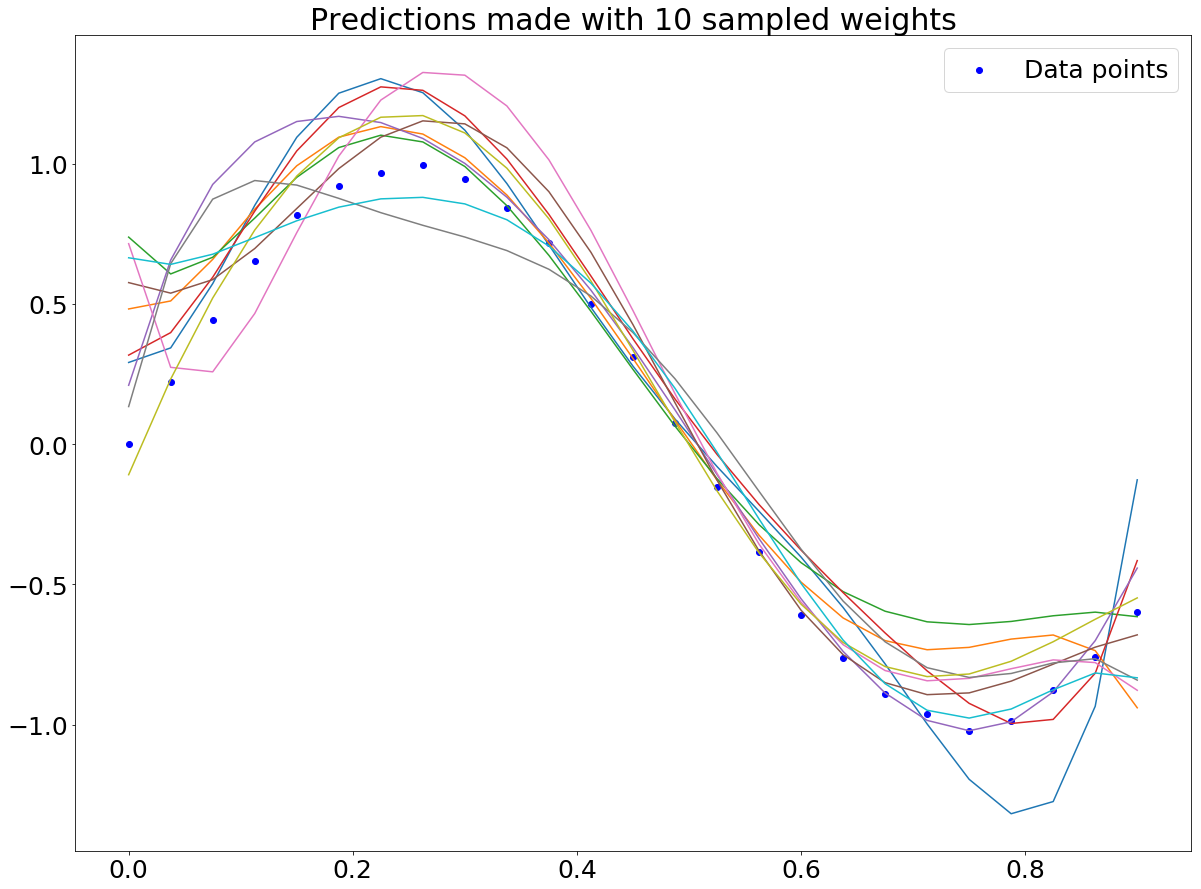

In [191]:
n_weights = 10
X_200 = gaussian(points, np.linspace(-0.5, 1, 10), 0.7)  #测试集
print(np.shape(X))
def plot_some_functions(n_weights):
    for _ in range(n_weights):
        sampled_w = np.random.multivariate_normal(np.squeeze(m_post), S_post)
        print(np.shape(sampled_w))
        plt.plot(x, X @ sampled_w)
plot_some_functions(n_weights)   
plot_it('Predictions made with {} sampled weights'.format(n_weights))